# BERTopic-Driven Stock Market Predictions: Unraveling Sentiment Insights
## Reproduction de la méthodologie du papier scientifique


***Import des librairies***

In [4]:
# Installation et imports de toutes les bibliothèques nécessaires
# Inclure : pandas, numpy, sklearn, tensorflow/keras, transformers, bertopic, 
# vader, matplotlib, seaborn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import re
import string


**SECTION 1 : Chargement et Exploration des Données**

***Chargement des données***

In [8]:
# Charger le dataset contenant les tweets pour les 27 actions
# Colonnes attendues : Date, Tweet, Stock Name, Company Name
# Vérifier la structure du dataset et afficher les premières lignes

#Charger les données de marché (prix, volume) pour les 27 actions
# Colonnes attendues : Date, Open, High, Low, Close, Adj Close, Volume, Stock Name
# Vérifier la correspondance des dates entre tweets et données boursières
# Paths 
tweets_path = 'stock_tweets.csv'

# Charger tweets et price data
tweets_df = pd.read_csv(tweets_path)
# basic info
print('Tweets shape:', tweets_df.shape)

Tweets shape: (80793, 4)


In [9]:
#Exploration des données de tweets. 

print("APERÇU DES DONNÉES de TWEETS")
print(tweets_df.head())
print("=" * 80)

print("INFORMATIONS SUR LES COLONNES")
print(tweets_df.info())
print("=" * 80)

print("VALEURS MANQUANTES")
print(tweets_df.isnull().sum())
print("=" * 80)
print("ACTIONS PRÉSENTES DANS LE DATASET")
unique_stocks = tweets_df['Stock Name'].unique()
print(f"Nombre d'actions uniques : {len(unique_stocks)}")
print(f"Liste des actions : {sorted(unique_stocks)}")

#Conversion de la colonne Date en format datetime
tweets_df['Date'] = pd.to_datetime(tweets_df['Date'])

# Extraire uniquement la date (sans l'heure) pour les agrégations quotidiennes
tweets_df['Date_only'] = tweets_df['Date'].dt.date
print("=" * 80)
print("PÉRIODE COUVERTE PAR LES DONNÉES")
print(f"Date de début : {tweets_df['Date'].min()}")
print(f"Date de fin   : {tweets_df['Date'].max()}")


APERÇU DES DONNÉES de TWEETS
                        Date  \
0  2022-09-29 23:41:16+00:00   
1  2022-09-29 23:24:43+00:00   
2  2022-09-29 23:18:08+00:00   
3  2022-09-29 22:40:07+00:00   
4  2022-09-29 22:27:05+00:00   

                                               Tweet Stock Name Company Name  
0  Mainstream media has done an amazing job at br...       TSLA  Tesla, Inc.  
1  Tesla delivery estimates are at around 364k fr...       TSLA  Tesla, Inc.  
2  3/ Even if I include 63.0M unvested RSUs as of...       TSLA  Tesla, Inc.  
3  @RealDanODowd @WholeMarsBlog @Tesla Hahaha why...       TSLA  Tesla, Inc.  
4  @RealDanODowd @Tesla Stop trying to kill kids,...       TSLA  Tesla, Inc.  
INFORMATIONS SUR LES COLONNES
<class 'pandas.DataFrame'>
RangeIndex: 80793 entries, 0 to 80792
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Date          80793 non-null  str  
 1   Tweet         80793 non-null  str  
 2   Stock Na

In [10]:
# Supprimer les tweets avec 1 ou 2 mots
tweets_df['word_count'] = tweets_df['Tweet'].str.split().str.len()

# Filtrer : garder uniquement les tweets avec au moins 3 mots
tweets_df = tweets_df[tweets_df['word_count'] >= 3].copy()

tweets_df.drop(columns=['word_count'], inplace=True)

print(f"Nombre de tweets après filtrage : {len(tweets_df)}")


Nombre de tweets après filtrage : 80671


# ***Analyse exploratoire des tweets***

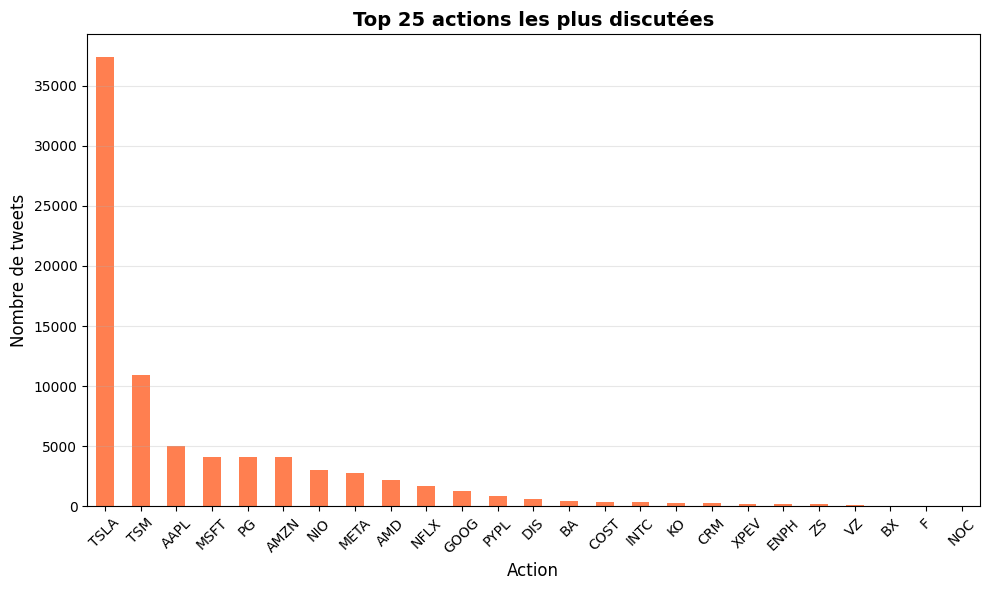

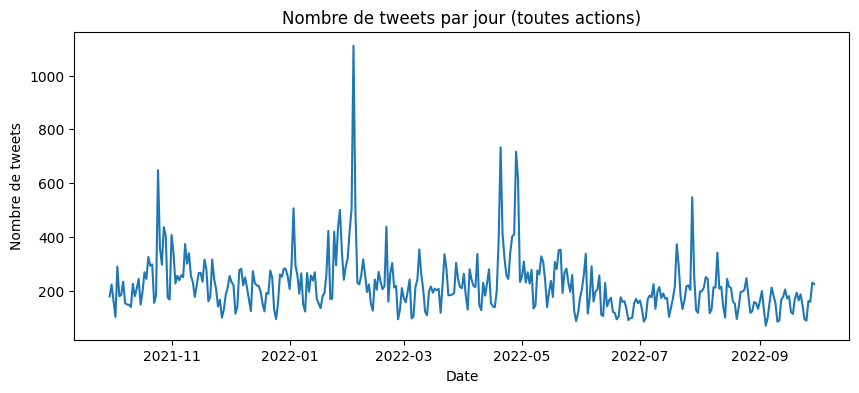

Longueur moyenne des tweets: 27.42 mots


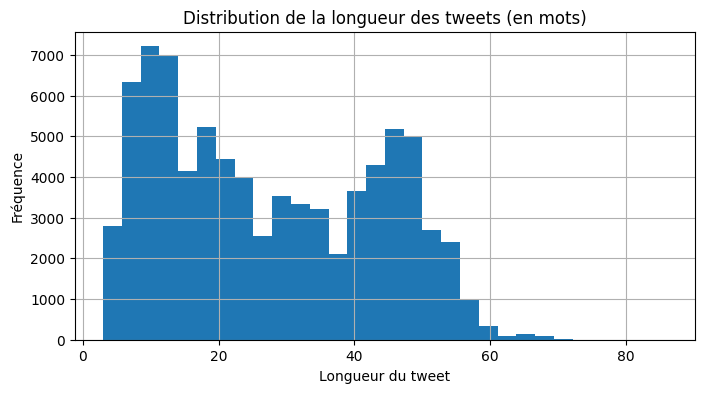

In [12]:
#Statistiques descriptives sur les tweets
# - Nombre de tweets par action
# - Distribution temporelle des tweets
# - Longueur moyenne des tweets
# - Visualisations (histogrammes, time series)


# Statistiques descriptives sur les tweets

# Nombre de tweets par action
tweets_per_stock = (
    tweets_df['Stock Name']
    .value_counts()
    .sort_values(ascending=False)
)

# Graphique : Top 25 actions
plt.figure(figsize=(10, 6))
tweets_per_stock.head(25).plot(kind='bar', color='coral')

plt.xlabel('Action', fontsize=12)
plt.ylabel('Nombre de tweets', fontsize=12)
plt.title('Top 25 actions les plus discutées', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution temporelle des tweets
distribution_temporelle = tweets_df.groupby('Date_only')['Tweet'].count()

plt.figure(figsize=(10,4))
distribution_temporelle.plot(kind='line')
plt.title("Nombre de tweets par jour (toutes actions)")
plt.xlabel("Date")
plt.ylabel("Nombre de tweets")
plt.show()

# Longueur moyenne des tweets (en mots)
tweets_df['longueur'] = tweets_df['Tweet'].astype(str).apply(lambda x: len(x.split()))
longueur_moyenne_globale = tweets_df['longueur'].mean()
print(f"Longueur moyenne des tweets: {longueur_moyenne_globale:.2f} mots")

# Histogramme de la longueur des tweets
plt.figure(figsize=(8,4))
tweets_df['longueur'].hist(bins=30)
plt.title("Distribution de la longueur des tweets (en mots)")
plt.xlabel("Longueur du tweet")
plt.ylabel("Fréquence")
plt.show()

# **SECTION 2 : Prétraitement des Tweets**

## ***Nettoyage des tweets***

In [14]:
# Prétraitement du texte des tweets
# - Suppression des URLs, mentions (@), hashtags si nécessaire
# - Suppression des caractères spéciaux
# - Conversion en minuscules (optionnel selon la méthode)
# - Gestion des emojis (VADER les utilise, donc les conserver)
# Note : Le papier utilise VADER qui gère bien les emojis et la ponctuation

In [13]:
# Fonction de prétraitement
def preprocess_tweet(text):
    """
    Prétraite un tweet en conservant les emojis et la ponctuation pour VADER
    
    Args:
        text: le texte du tweet
    
    Returns:
        text nettoyé
    """
    text = str(text)
    
    # 0. Décoder les entités HTML (amp, gt, lt, etc.)
    import html
    text = html.unescape(text)
    
    # 1. Supprimer les URLs (http, https, www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 2. Supprimer les mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # 3. Gérer les cashtags et montants différemment
    # a) Remplacer les tickers $AAPL par TICKER_AAPL (pour les identifier)
    text = re.sub(r'\$([A-Z]{1,5})(?!\d)', r'TICKER_\1', text)
    
    # b) Remplacer les montants $123.45 par AMOUNT_123.45 (pour les préserver)
    text = re.sub(r'\$(\d+(?:\.\d+)?[BMK]?)', r'AMOUNT_\1', text)
    
    # 4. Remplacer les hashtags par le texte sans #
    # Ex: #bullish -> bullish
    text = re.sub(r'#(\w+)', r'\1', text)
    
    # 5. Gérer les pourcentages (les garder)
    text = re.sub(r'(\d+(?:\.\d+)?)\s*%', r'\1percent', text)
    
    # 6. Remplacer les slashes par des espaces (sauf dans les dates)
    text = re.sub(r'(\d+)/(\d+)/(\d+)', r'\1-\2-\3', text)  # dates
    text = re.sub(r'/', ' ', text)  # autres slashes
    
    # 7. Supprimer les caractères spéciaux SAUF ponctuation et emojis
    # On garde : lettres, chiffres, espaces, ponctuation (!?.,;:), apostrophes, tirets, underscores
    text = re.sub(r'[^\w\s!?.,;:\'\"-]', ' ', text, flags=re.UNICODE)
    
    # 8. Supprimer les nombres isolés de 1-2 chiffres en début de tweet (numérotation)
    text = re.sub(r'^\d{1,2}\s+', '', text)
    
    # 9. Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text)
    
    # 10. Retirer les espaces en début et fin
    text = text.strip()
    
    # Note: On NE convertit PAS en minuscules car :
    # - VADER utilise les majuscules pour détecter l'intensité ("GOOD" vs "good")
    # - BERT gère bien la casse
    
    return text


In [14]:
#Appliquer le prétraitement à tous les tweets
tweets_df['Tweet_original'] = tweets_df['Tweet']  # Sauvegarder l'original
tweets_df['Tweet_clean'] = tweets_df['Tweet'].apply(preprocess_tweet)

# Vérifier les tweets vides après nettoyage
empty_tweets = tweets_df[tweets_df['Tweet_clean'].str.strip() == '']
print(f"Nombre de tweets vides après nettoyage : {len(empty_tweets)}")

Nombre de tweets vides après nettoyage : 0


In [16]:
# ============================================================
# Cap du volume de tweets par action (max 5000) — exigence projet
# Stratégie: échantillonnage aléatoire reproductible *par action*.
# (Option: stratifier par date si tu veux une meilleure couverture temporelle.)
# ============================================================

MAX_TWEETS_PER_STOCK = 5000
RANDOM_STATE = 42

# Parse dates
tweets_df['Date'] = pd.to_datetime(tweets_df['Date'], utc=True, errors='coerce')

# Nettoyer les lignes sans date/tweet
tweets_df = tweets_df.dropna(subset=['Date', 'Tweet_clean', 'Stock Name']).copy()

def cap_tweets_per_stock(df, max_n=5000, random_state=42):
    out = []
    for ticker, g in df.groupby('Stock Name', sort=True):
        if len(g) > max_n:
            g = g.sample(n=max_n, random_state=random_state)
        out.append(g)
    return pd.concat(out, ignore_index=True)

tweets_df_capped = cap_tweets_per_stock(tweets_df, MAX_TWEETS_PER_STOCK, RANDOM_STATE)

print('Tweets avant cap:', len(tweets_df), '| après cap:', len(tweets_df_capped))
display(tweets_df['Stock Name'].value_counts().head(10))
display(tweets_df_capped['Stock Name'].value_counts().head(10))

Tweets avant cap: 80671 | après cap: 42252


Stock Name
TSLA    37414
TSM     10954
AAPL     5051
MSFT     4087
PG       4087
AMZN     4087
NIO      3019
META     2751
AMD      2226
NFLX     1716
Name: count, dtype: int64

Stock Name
AAPL    5000
TSLA    5000
TSM     5000
AMZN    4087
MSFT    4087
PG      4087
NIO     3019
META    2751
AMD     2226
NFLX    1716
Name: count, dtype: int64

In [14]:
comparison_df = tweets_df_capped[['Tweet_original', 'Tweet_clean']].head(5)
for idx, row in comparison_df.iterrows():
    print(f"\n--- Tweet {idx} ---")
    print(f"AVANT : {row['Tweet_original'][:150]}...")
    print(f"APRÈS : {row['Tweet_clean'][:150]}...")
    print("-" * 80)



--- Tweet 0 ---
AVANT : Sell $41,000 worth of $AAPL for 1,000 more shares of $NIO 🤔🤔🤔...
APRÈS : Sell AMOUNT_41,000 worth of TICKER_AAPL for 1,000 more shares of TICKER_NIO...
--------------------------------------------------------------------------------

--- Tweet 1 ---
AVANT : $AAPL CFO, Luca Maestri, filed Form 144 paperwork with the SEC to sell 96,735 shares, worth an estimated $16.9 million....
APRÈS : TICKER_AAPL CFO, Luca Maestri, filed Form 144 paperwork with the SEC to sell 96,735 shares, worth an estimated AMOUNT_16.9 million....
--------------------------------------------------------------------------------

--- Tweet 2 ---
AVANT : $AAPL they’re gonna say the news is fake and then it’s gonna pump again lol...
APRÈS : TICKER_AAPL they re gonna say the news is fake and then it s gonna pump again lol...
--------------------------------------------------------------------------------

--- Tweet 3 ---
AVANT : We don’t bet against $AAPL. It’s the one stock I will never short, 

In [17]:
tweets_df_capped.to_csv('stock_tweets_cleaned_capped.csv', index=False)

In [23]:
'''
# ============================================================
# Sentiment scoring — VADER (rapide) + BERT/FinBERT (optionnel)
# On calcule:
#  - vader_compound: score ∈ [-1,1] par tweet
#  - bert_score: score ∈ [-1,1] par tweet (si modèle dispo)
# ============================================================

from tqdm.auto import tqdm

# VADER
vader = SentimentIntensityAnalyzer()

def vader_compound(text: str) -> float:
    if not isinstance(text, str) or text.strip() == "":
        return np.nan
    return float(vader.polarity_scores(text)["compound"])

tqdm.pandas()
tweets_df_capped["vader_compound"] = tweets_df_capped["Tweet_clean"].progress_apply(vader_compound)

print(" VADER terminé. Aperçu:")
display(tweets_df_capped[["Stock Name","Date","Tweet_clean","vader_compound"]].head(3))

# BERT/FinBERT (optionnel, plus lent)
BERT_MODEL_NAME = "ProsusAI/finbert"  # FinBERT (finance). Alternative: "distilbert-base-uncased-finetuned-sst-2-english"
USE_BERT = USE_FINBERT  # dépend des imports au début

if USE_BERT:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME).to(device)
    model.eval()

    # FinBERT labels typiques: positive/negative/neutral
    id2label = {int(k):v for k,v in model.config.id2label.items()} if hasattr(model.config,"id2label") else None
    label2id = {v:int(k) for k,v in id2label.items()} if id2label else None

    def finbert_to_score(probs: np.ndarray) -> float:
        # Convertit (p_neg, p_neu, p_pos) => score [-1,1] = p_pos - p_neg
        # On détecte l'ordre via id2label si possible.
        if probs.ndim != 1:
            probs = probs.ravel()
        if id2label:
            # map indices
            p_pos = float(probs[label2id.get("positive", 2)])
            p_neg = float(probs[label2id.get("negative", 0)])
        else:
            # fallback hypothèse (neg, neu, pos)
            p_neg = float(probs[0]); p_pos = float(probs[-1])
        return p_pos - p_neg

    @torch.no_grad()
    def bert_scores(texts, batch_size=32, max_length=128):
        scores=[]
        for i in tqdm(range(0, len(texts), batch_size), desc="BERT scoring"):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
            enc = {k:v.to(device) for k,v in enc.items()}
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
            batch_scores = [finbert_to_score(p) for p in probs]
            scores.extend(batch_scores)
        return scores

    texts = tweets_df_capped["Tweet_clean"].fillna("").tolist()
    tweets_df_capped["bert_score"] = bert_scores(texts, batch_size=32, max_length=128)
    print(" BERT terminé. Aperçu:")
    display(tweets_df_capped[["Stock Name","Date","bert_score"]].head(3))
else:
    tweets_df_capped["bert_score"] = np.nan
    print(" Transformers/torch non dispo → 'bert_score' mis à NaN .")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42252/42252 [00:16<00:00, 2615.65it/s]

✅ VADER terminé. Aperçu:


,Stock Name,Date,Tweet_clean,vader_compound
0,AAPL,2021-11-02 00:27:27+00:00,"Sell AMOUNT_41,000 worth of TICKER_AAPL for 1,...",0.5256
1,AAPL,2022-08-18 20:34:48+00:00,"TICKER_AAPL CFO, Luca Maestri, filed Form 144 ...",0.4767
2,AAPL,2022-09-28 13:09:01+00:00,TICKER_AAPL they re gonna say the news is fake...,-0.0772


Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 295.38it/s, Materializing param=classifier.weight]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BERT scoring: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1321/1321 [1:46:43<00:00,  4.85s/it]

✅ BERT terminé. Aperçu:


,Stock Name,Date,bert_score
0,AAPL,2021-11-02 00:27:27+00:00,0.013655
1,AAPL,2022-08-18 20:34:48+00:00,0.015795
2,AAPL,2022-09-28 13:09:01+00:00,-0.064033


In [29]:
'''
tweets_df_capped.to_csv(
    "tweetsVaderBert.csv",
    index=False,        # usually you don't want the pandas index in the CSV
    encoding="utf-8-sig"  # avoids weird accents issues in Excel (Windows)
)

In [20]:
tweets_df_capped = pd.read_csv(
    "tweetsVaderBert.csv",
    encoding="utf-8-sig"
)

In [22]:
# ============================================================
# BERTopic par action + sentiment au niveau des topics (OPTIMISÉ)
# On produit:
# - topic_id (par tweet)
# - topic_sentiment_vader / topic_sentiment_bert (par tweet via son topic)
# - score_topic_vader / score_topic_bert (agrégé par jour & action)
#
# Optimisations:
# - 1 seul embedding model chargé (pas de reload -> plus de "Loading weights" en boucle)
# - embeddings calculés explicitement + passés à BERTopic (fit + transform)
# - on entraîne sur un sous-échantillon MAX_DOCS_FOR_TOPICS (rapide) puis on assigne à tous les tweets
# - on désactive calculate_probabilities + nr_topics="auto" (très coûteux)
# - logs HF/Transformers réduits
# ============================================================

import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# --- Réduire le bruit HF/Transformers (warning + barres de téléchargement) ---
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

try:
    from transformers import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

try:
    from huggingface_hub.utils import logging as hub_logging
    hub_logging.set_verbosity_error()
except Exception:
    pass

from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

# -------------------------
# Paramètres
# -------------------------
BERTOPIC_LANGUAGE = "english"
BERTOPIC_MIN_TOPIC_SIZE = 10

# Le plus gros levier: entraîner BERTopic sur un sous-échantillon par action
MAX_DOCS_FOR_TOPICS = 1500  # 800–2000 typiquement; augmente si tu as GPU/CPU costaud

# Embeddings (chargés UNE fois)
EMB_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
EMB_BATCH_FIT = 128
EMB_BATCH_TRANSFORM = 256

embedding_model = SentenceTransformer(EMB_MODEL_NAME, device="cpu")  # mets "cuda" si tu as GPU


def encode_texts(texts, model, batch_size=128):
    """Encode texts -> embeddings numpy, sans progress bar."""
    return model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True
    )


def fit_topics_for_stock(texts, embeddings, min_topic_size=10):
    """Fit BERTopic sur texts + embeddings. Retourne (model, topics, probs)."""
    if len(texts) < max(50, min_topic_size * 3):
        return None, None, None  # pas assez de docs

    model = BERTopic(
        language=BERTOPIC_LANGUAGE,
        min_topic_size=min_topic_size,
        nr_topics=None,                 # IMPORTANT: éviter "auto" (très coûteux)
        verbose=False,
        calculate_probabilities=False   # gagne du temps
    )

    topics, probs = model.fit_transform(texts, embeddings=embeddings)
    return model, topics, probs


# -------------------------
# Entraîner / assigner topics
# -------------------------
topic_models = {}
topic_ids_all = np.full(len(tweets_df_capped), fill_value=-1, dtype=int)

groups = tweets_df_capped.groupby("Stock Name").groups

for ticker, idxs in tqdm(list(groups.items()), desc="BERTopic per stock"):
    idxs = list(idxs)
    if len(idxs) < max(50, BERTOPIC_MIN_TOPIC_SIZE * 3):
        continue

    # 1) Sous-échantillon pour l'entraînement (rapide)
    if len(idxs) > MAX_DOCS_FOR_TOPICS:
        idxs_fit = tweets_df_capped.loc[idxs].sample(MAX_DOCS_FOR_TOPICS, random_state=42).index.tolist()
    else:
        idxs_fit = idxs

    texts_fit = tweets_df_capped.loc[idxs_fit, "Tweet_clean"].fillna("").tolist()
    emb_fit = encode_texts(texts_fit, embedding_model, batch_size=EMB_BATCH_FIT)

    model, _, _ = fit_topics_for_stock(texts_fit, emb_fit, min_topic_size=BERTOPIC_MIN_TOPIC_SIZE)
    if model is None:
        continue

    topic_models[ticker] = model

    # 2) Assignation des topics à TOUS les tweets de l'action (transform)
    texts_all = tweets_df_capped.loc[idxs, "Tweet_clean"].fillna("").tolist()
    emb_all = encode_texts(texts_all, embedding_model, batch_size=EMB_BATCH_TRANSFORM)

    topics_all, _ = model.transform(texts_all, embeddings=emb_all)
    topic_ids_all[idxs] = np.asarray(topics_all, dtype=int)

tweets_df_capped["topic_id"] = topic_ids_all

print("✅ Topics assignés. Aperçu:")
display(tweets_df_capped[["Stock Name", "Date", "topic_id"]].head(5))
print("Actions avec modèle BERTopic:", len(topic_models), "/", tweets_df_capped["Stock Name"].nunique())


# ------------------------------------------------------------
# Sentiment par topic (moyenne des tweets du topic)
# ------------------------------------------------------------
def add_topic_sentiments(df):
    df = df.copy()
    df["topic_sentiment_vader"] = np.nan
    df["topic_sentiment_bert"] = np.nan

    for ticker, g in df.groupby("Stock Name", sort=True):
        if ticker not in topic_models:
            continue

        # VADER: moyenne par topic_id
        topic_mean_vader = g.groupby("topic_id")["vader_compound"].mean()
        df.loc[g.index, "topic_sentiment_vader"] = g["topic_id"].map(topic_mean_vader)

        # BERT/FinBERT: moyenne par topic_id (si dispo)
        if "bert_score" in g.columns and g["bert_score"].notna().any():
            topic_mean_bert = g.groupby("topic_id")["bert_score"].mean()
            df.loc[g.index, "topic_sentiment_bert"] = g["topic_id"].map(topic_mean_bert)

    return df


tweets_df_capped = add_topic_sentiments(tweets_df_capped)


# ------------------------------------------------------------
# Agrégation quotidienne (par action): score (tweet-level) et score_topic
# ------------------------------------------------------------
tweets_df_capped["Date_day"] = pd.to_datetime(tweets_df_capped["Date"]).dt.date

daily_sent = (
    tweets_df_capped
    .groupby(["Stock Name", "Date_day"], as_index=False)
    .agg(
        score=("vader_compound", "mean"),
        score_bert=("bert_score", "mean"),
        score_topic_vader=("topic_sentiment_vader", "mean"),
        score_topic_bert=("topic_sentiment_bert", "mean"),
        n_tweets=("Tweet_clean", "size"),
    )
)

daily_sent["Date"] = pd.to_datetime(daily_sent["Date_day"])
daily_sent = daily_sent.drop(columns=["Date_day"])

print(" Daily sentiment ready:")
display(daily_sent.head(5))




BERTopic per stock: 100%|███████████████████████████████████████████████████████████| 25/25 [15:53<00:00, 38.15s/it]

✅ Topics assignés. Aperçu:


,Stock Name,Date,topic_id
0,AAPL,2021-11-02 00:27:27+00:00,-1
1,AAPL,2022-08-18 20:34:48+00:00,4
2,AAPL,2022-09-28 13:09:01+00:00,-1
3,AAPL,2022-01-28 16:07:42+00:00,4
4,AAPL,2021-11-04 18:56:04+00:00,-1


Actions avec modèle BERTopic: 23 / 25
✅ Daily sentiment ready:


,Stock Name,score,score_bert,score_topic_vader,score_topic_bert,n_tweets,Date
0,AAPL,0.098900,-0.081460,0.154101,-0.003312,7,2021-09-30
1,AAPL,0.291891,-0.054302,0.137059,-0.046683,11,2021-10-01
2,AAPL,0.007525,-0.027083,0.221226,-0.010609,4,2021-10-02
3,AAPL,0.834400,0.038217,0.315096,-0.028098,1,2021-10-03
4,AAPL,0.047410,-0.088765,0.256343,-0.007162,10,2021-10-04


In [23]:
# ============================================================
# Features de marché (papier): indicateurs techniques + merge avec sentiments
# ============================================================

prices = prices_df.copy()
prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.sort_values(["Stock Name","Date"]).reset_index(drop=True)

def add_technical_indicators(df):
    df = df.copy()
    # MA7 / MA20 sur Close
    df["MA7"] = df.groupby("Stock Name")["Close"].transform(lambda s: s.rolling(7).mean())
    df["MA20"] = df.groupby("Stock Name")["Close"].transform(lambda s: s.rolling(20).mean())

    # MACD = EMA12 - EMA26
    ema12 = df.groupby("Stock Name")["Close"].transform(lambda s: s.ewm(span=12, adjust=False).mean())
    ema26 = df.groupby("Stock Name")["Close"].transform(lambda s: s.ewm(span=26, adjust=False).mean())
    df["MACD"] = ema12 - ema26

    # 20SD + Bollinger
    df["20SD"] = df.groupby("Stock Name")["Close"].transform(lambda s: s.rolling(20).std())
    df["upper_band"] = df["MA20"] + (df["20SD"] * 2)
    df["lower_band"] = df["MA20"] - (df["20SD"] * 2)

    # EMA (papier: non précisé → on garde EMA (span=20) sur Close)
    df["EMA"] = df.groupby("Stock Name")["Close"].transform(lambda s: s.ewm(span=20, adjust=False).mean())

    # log momentum (papier: log(momentum))
    # momentum = Close(t) - Close(t-1)
    mom = df.groupby("Stock Name")["Close"].diff(1)
    df["log_momentum"] = np.log1p(mom.clip(lower=0))  # robust: évite log de négatif
    return df

prices_feat = add_technical_indicators(prices)

# Merge: prix + sentiments (left join prix, car il y a des jours de marché sans tweets)
full = prices_feat.merge(daily_sent, on=["Stock Name","Date"], how="left")

# Remplir sentiments manquants par 0 (hypothèse neutre)
for col in ["score","score_bert","score_topic_vader","score_topic_bert"]:
    if col in full.columns:
        full[col] = full[col].fillna(0.0)

# Drop NaN techniques dues aux rolling windows (au moins MA20/20SD)
full = full.dropna(subset=["MA20","20SD","MA7","MACD","upper_band","lower_band","EMA","log_momentum"]).reset_index(drop=True)

print(" Dataset final prêt:", full.shape)
display(full.head(3))

 Dataset final prêt: (5825, 23)


,Date,Open,High,Low,Close,Adj Close,Volume,Stock Name,Date_only,Daily_Return,...,20SD,upper_band,lower_band,EMA,log_momentum,score,score_bert,score_topic_vader,score_topic_bert,n_tweets
0,2021-10-27,149.360001,149.729996,148.490005,148.850006,147.775421,56094900,AAPL,2021-10-27,-0.003148,...,3.502950,151.804399,137.792598,145.818909,0.000000,-0.033136,-0.009908,0.163375,-0.030896,14.0
1,2021-10-28,149.820007,153.169998,149.720001,152.570007,151.468567,100077900,AAPL,2021-10-28,0.024992,...,3.815009,152.982017,137.721981,146.461870,1.551809,0.026876,-0.196515,0.126975,-0.018059,29.0
2,2021-10-29,147.220001,149.940002,146.410004,149.800003,148.718567,124953200,AAPL,2021-10-29,-0.018156,...,3.882887,153.475272,137.943726,146.779788,0.000000,0.226593,0.071645,0.141664,0.000077,30.0


In [26]:
'''
full.to_csv(
    "FullDataset.csv",
    index=False,        # usually you don't want the pandas index in the CSV
    encoding="utf-8-sig"  # avoids weird accents issues in Excel (Windows)
)

In [19]:
import pandas as pd
full = pd.read_csv(
    "fullDataset.csv",
    encoding="utf-8-sig"
)

In [20]:
# ============================================================
# 5 VARIANTS DE FEATURES (selon ta demande)
# ============================================================

BASE_FEATURES = [
    "Open","High","Low","Close","Volume",
    "MA7","MA20","MACD","20SD","upper_band","lower_band",
    "EMA","log_momentum"
]

FEATURE_VARIANTS = {
    # 1) without scores only the rest of features
    "no_scores": BASE_FEATURES,

    # 2) only score
    "only_score": BASE_FEATURES + ["score"],

    # 3) only score_bert
    "only_score_bert": BASE_FEATURES + ["score_bert"],

    # 4) score and score-topic_vader
    "score_plus_topic_vader": BASE_FEATURES + ["score", "score_topic_vader"],

    # 5) score_bert and score_topic_bert
    "score_bert_plus_topic_bert": BASE_FEATURES + ["score_bert", "score_topic_bert"],
}

TARGET = "Adj Close"



In [23]:
# ============================================================
# Modélisation (papier): LSTM / CNN / CNN-LSTM — train sur (T-20) derniers jours
# Objectif: prédire Adj Close (scaled), évaluer sur les 20 derniers jours.
# ============================================================

# Imports DL (TensorFlow)
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Flatten
    from tensorflow.keras.callbacks import EarlyStopping
    TF_OK = True
except Exception as e:
    TF_OK = False
    print(" TensorFlow indisponible. Installe-le", e)

LOOKBACK = 10
TEST_HORIZON = 20
EPOCHS = 50
BATCH_SIZE = 32

BASE_FEATURES = ["Open","High","Low","Close","Volume","MA7","MA20","MACD","20SD","upper_band","lower_band","EMA","log_momentum"]
FEATS_LSTM_BASE = BASE_FEATURES
FEATS_LSTM_TOPIC = BASE_FEATURES + ["score_topic_vader"]   # papier: topic sentiment améliore
TARGET = "Adj Close"

def make_supervised_sequences(df_stock, feature_cols, target_col, lookback):
    X, y = [], []
    vals_X = df_stock[feature_cols].values
    vals_y = df_stock[target_col].values
    for t in range(lookback, len(df_stock)):
        X.append(vals_X[t-lookback:t, :])
        y.append(vals_y[t])
    return np.array(X), np.array(y)

def metrics_reg(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    mape = float(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100.0)
    return {"RMSE":rmse,"MAE":mae,"R2":r2,"MAPE%":mape}

def build_lstm(input_shape):
    m = Sequential([
        LSTM(50, activation="relu", input_shape=input_shape),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def build_cnn(input_shape):
    # Conv1D attends (timesteps, features)
    m = Sequential([
        Conv1D(filters=64, kernel_size=2, activation="relu", input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(50, activation="relu"),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def build_cnn_lstm(input_shape):
    m = Sequential([
        Conv1D(filters=64, kernel_size=2, activation="relu", input_shape=input_shape),
        LSTM(50, activation="relu"),
        Dense(1)
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def train_eval_one_stock(df_stock, feature_cols, model_builder, lookback=10, test_horizon=20):
    df_stock = df_stock.sort_values("Date").reset_index(drop=True)

    # split (chronologique) après création des séquences → on split par index
    # scaling: fit scaler sur train uniquement
    n = len(df_stock)
    if n <= lookback + test_horizon + 30:
        return None  # pas assez d'historique

    train_end = n - test_horizon

    # scalers
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_all = df_stock[feature_cols].values
    y_all = df_stock[[TARGET]].values

    X_train_raw = X_all[:train_end]
    y_train_raw = y_all[:train_end]

    X_scaled = scaler_X.fit_transform(X_train_raw)
    X_scaled_all = np.vstack([X_scaled, scaler_X.transform(X_all[train_end:])])

    y_scaled = scaler_y.fit_transform(y_train_raw)
    y_scaled_all = np.vstack([y_scaled, scaler_y.transform(y_all[train_end:])])

    df_scaled = df_stock.copy()
    df_scaled[feature_cols] = X_scaled_all
    df_scaled[TARGET] = y_scaled_all

    X_seq, y_seq = make_supervised_sequences(df_scaled, feature_cols, TARGET, lookback)
    # Alignement: la première cible correspond à l'index lookback
    seq_train_end = train_end - lookback
    X_train, y_train = X_seq[:seq_train_end], y_seq[:seq_train_end]
    X_test, y_test = X_seq[seq_train_end:], y_seq[seq_train_end:]

    # DL
    if not TF_OK:
        return None

    model = model_builder(input_shape=X_train.shape[1:])
    es = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)
    model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, callbacks=[es])

    pred_train = model.predict(X_train, verbose=0).ravel()
    pred_test = model.predict(X_test, verbose=0).ravel()

    # inverse scaling vers niveaux réels
    y_train_true = scaler_y.inverse_transform(y_train.reshape(-1,1)).ravel()
    y_test_true = scaler_y.inverse_transform(y_test.reshape(-1,1)).ravel()
    y_train_pred = scaler_y.inverse_transform(pred_train.reshape(-1,1)).ravel()
    y_test_pred = scaler_y.inverse_transform(pred_test.reshape(-1,1)).ravel()

    return {
        "train": metrics_reg(y_train_true, y_train_pred),
        "test": metrics_reg(y_test_true, y_test_pred),
        "n_obs": n,
        "n_test": len(y_test_true),
    }


In [24]:
# ------------------------------------------------------------
# Boucle multi-actions × 5 variants × 3 modèles DL
# ------------------------------------------------------------
results = []

DL_MODELS = {
    "LSTM": build_lstm,
    "CNN": build_cnn,
    "CNN-LSTM": build_cnn_lstm,
}

for ticker, df_s in full.groupby("Stock Name", sort=True):

    for variant_name, feat_cols in FEATURE_VARIANTS.items():

        # skip si colonnes sentiment manquantes (ou features mal générées)
        missing = [c for c in feat_cols if c not in df_s.columns]
        if missing:
            print(f"[SKIP] {ticker} / {variant_name} — colonnes manquantes: {missing}")
            continue

        for model_name, builder in DL_MODELS.items():
            r = train_eval_one_stock(
                df_s,
                feature_cols=feat_cols,
                model_builder=builder,
                lookback=LOOKBACK,
                test_horizon=TEST_HORIZON
            )
            if r:
                results.append({
                    "Stock": ticker,
                    "Model": model_name,
                    "Variant": variant_name,
                    **r["test"],
                    "n_obs": r["n_obs"],
                    "n_test": r["n_test"],
                })

results_df = (
    pd.DataFrame(results)
      .sort_values(["Stock","Model","Variant"])
      .reset_index(drop=True)
)

print("Résultats (test horizon = 20 jours) — 5 variants:")
display(results_df)


D:\M2_MoSEF\Project_Finance\Quantitative_finance_Project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
D:\M2_MoSEF\Project_Finance\Quantitative_finance_Project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
D:\M2_MoSEF\Project_Finance\Quantitative_finance_Project\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first l

Résultats (test horizon = 20 jours) — 5 variants:


,Stock,Model,Variant,RMSE,MAE,R2,MAPE%,n_obs,n_test
0,AAPL,CNN,no_scores,4.462186,3.688306,-0.225374,2.409158,233,20
1,AAPL,CNN,only_score,4.486257,3.737391,-0.238630,2.439733,233,20
2,AAPL,CNN,only_score_bert,6.196657,5.012694,-1.363134,3.280545,233,20
3,AAPL,CNN,score_bert_plus_topic_bert,5.313054,4.004102,-0.737248,2.615435,233,20
4,AAPL,CNN,score_plus_topic_vader,4.544403,3.521302,-0.270946,2.315920,233,20
...,...,...,...,...,...,...,...,...,...
370,ZS,LSTM,no_scores,13.242204,9.643545,0.103803,5.548447,233,20
371,ZS,LSTM,only_score,13.220810,9.087566,0.106696,5.239580,233,20
372,ZS,LSTM,only_score_bert,10.049708,6.670428,0.483833,3.904670,233,20
373,ZS,LSTM,score_bert_plus_topic_bert,12.386572,8.481572,0.215875,4.910760,233,20


In [41]:
results_df.to_csv("All_results.csv")

In [25]:
# ============================================================
# GRAPHIQUES RÉSUMÉ MULTI-STOCKS — 5 VARIANTS
# Boxplot RMSE + Gain moyen vs baseline + Heatmap + Win rate
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTDIR = "paper_outputs"
FIGDIR_SUM = os.path.join(OUTDIR, "figures_summary")
TABDIR = os.path.join(OUTDIR, "tables")
os.makedirs(FIGDIR_SUM, exist_ok=True)
os.makedirs(TABDIR, exist_ok=True)

assert "results_df" in globals() and not results_df.empty, "results_df absent ou vide."

res_plot = results_df.copy()
models = sorted(res_plot["Model"].unique())
variants = list(FEATURE_VARIANTS.keys())  # ordre défini plus haut

BASELINE = "no_scores"  # baseline = sans sentiment

# ------------------------------------------------------------
# 1) Boxplot RMSE par modèle × variant
# ------------------------------------------------------------
groups, labels = [], []
for m in models:
    for v in variants:
        vals = res_plot[(res_plot["Model"] == m) & (res_plot["Variant"] == v)]["RMSE"].dropna().values
        groups.append(vals)
        labels.append(f"{m}\n{v}")

plt.figure(figsize=(14, 5))
plt.boxplot(groups, labels=labels, showfliers=True)
plt.title("Distribution des RMSE (Test) — Modèle × Variant")
plt.ylabel("RMSE")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR_SUM, "BOXPLOT_RMSE_MODELES_VARIANTS.png"), dpi=200)
plt.close()

# ------------------------------------------------------------
# 2) Gain moyen vs baseline
# ΔRMSE = RMSE_baseline - RMSE_variant (positif = amélioration)
# ------------------------------------------------------------
pivot = res_plot.pivot_table(index=["Stock","Model"], columns="Variant", values="RMSE", aggfunc="mean")
pivot = pivot.dropna(subset=[BASELINE], how="any")

delta = []
for (stock, model), row in pivot.iterrows():
    base = row.get(BASELINE, np.nan)
    for v in variants:
        if v == BASELINE:
            continue
        if v in row.index and pd.notna(row[v]) and pd.notna(base):
            delta.append({"Stock": stock, "Model": model, "Variant": v, "Delta_RMSE": base - row[v]})

delta_df = pd.DataFrame(delta)

gain_by_model = (
    delta_df.groupby(["Model","Variant"])["Delta_RMSE"]
            .mean()
            .reset_index()
)

# bar groupée par modèle
plt.figure(figsize=(12, 4))
x = np.arange(len(models))
width = 0.16
alts = [v for v in variants if v != BASELINE]

for k, v in enumerate(alts):
    vals = []
    for m in models:
        tmp = gain_by_model[(gain_by_model["Model"] == m) & (gain_by_model["Variant"] == v)]
        vals.append(float(tmp["Delta_RMSE"].values[0]) if len(tmp) else 0.0)
    plt.bar(x + k*width, vals, width=width, label=v)

plt.axhline(0, linewidth=1)
plt.title(f"Gain moyen vs baseline ({BASELINE}) — ΔRMSE = baseline − variant")
plt.ylabel("ΔRMSE (positif = amélioration)")
plt.xticks(x + width*1.5, models)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR_SUM, "BAR_GAIN_MOYEN_VS_BASELINE.png"), dpi=200)
plt.close()

# ------------------------------------------------------------
# 3) Heatmap Stock × (Model|Variant) des gains ΔRMSE
# ------------------------------------------------------------
delta_df["ModelVariant"] = delta_df["Model"].astype(str) + " | " + delta_df["Variant"].astype(str)
heat = delta_df.pivot_table(index="Stock", columns="ModelVariant", values="Delta_RMSE", aggfunc="mean")
heat = heat.reindex(index=sorted(heat.index), columns=sorted(heat.columns))

plt.figure(figsize=(12, max(4, 0.35 * len(heat.index))))
plt.imshow(heat.values, aspect="auto")
plt.colorbar(label=f"ΔRMSE = {BASELINE} − variant")
plt.title("Heatmap gain vs baseline — par stock et (modèle|variant)")
plt.yticks(range(len(heat.index)), heat.index)
plt.xticks(range(len(heat.columns)), heat.columns, rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR_SUM, "HEATMAP_GAIN_VS_BASELINE.png"), dpi=200)
plt.close()

# ------------------------------------------------------------
# 4) Win rate: % stocks où variant bat baseline (ΔRMSE > 0)
# ------------------------------------------------------------
winrate = (
    delta_df.groupby(["Model","Variant"])["Delta_RMSE"]
            .apply(lambda s: (s > 0).mean() * 100.0)
            .reset_index(name="WinRate_%")
)

winrate.to_csv(os.path.join(TABDIR, "WINRATE_VS_BASELINE.csv"), index=False)

# plot winrate (bar groupée)
plt.figure(figsize=(12, 4))
for k, v in enumerate(alts):
    vals = []
    for m in models:
        tmp = winrate[(winrate["Model"] == m) & (winrate["Variant"] == v)]
        vals.append(float(tmp["WinRate_%"].values[0]) if len(tmp) else 0.0)
    plt.bar(x + k*width, vals, width=width, label=v)

plt.title(f"Win rate vs baseline ({BASELINE}) — % stocks avec ΔRMSE > 0")
plt.ylabel("% stocks améliorés")
plt.xticks(x + width*1.5, models)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR_SUM, "BAR_WINRATE_VS_BASELINE.png"), dpi=200)
plt.close()

# ------------------------------------------------------------
# Exports tables
# ------------------------------------------------------------
results_df.to_csv(os.path.join(TABDIR, "RESULTS_ALL_STOCKS_MODELS_VARIANTS.csv"), index=False)
delta_df.to_csv(os.path.join(TABDIR, "DELTA_RMSE_VS_BASELINE.csv"), index=False)

print("Graphiques sauvegardés dans:", FIGDIR_SUM)
print("Tables exportées dans:", TABDIR)


C:\Users\Juan David Alonso\AppData\Local\Temp\ipykernel_30516\3519823748.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


Graphiques sauvegardés dans: paper_outputs\figures_summary
Tables exportées dans: paper_outputs\tables


In [28]:
TABDIR = 'paper_outputs\\'

In [29]:
# ============================================================
# 5) TABLES MOYENNES POUR COMPARER LES MODÈLES / VARIANTS
# ============================================================

# A) Moyennes par Modèle × Variant (sur tous les stocks)
avg_model_variant = (
    results_df
    .groupby(["Model", "Variant"])
    .agg(
        n_stocks=("Stock", "nunique"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        R2_mean=("R2", "mean"),
        MAPE_mean=("MAPE%", "mean"),
    )
    .reset_index()
    .sort_values(["Model", "RMSE_mean", "Variant"])
)

display(avg_model_variant)
avg_model_variant.to_csv(os.path.join(TABDIR, "AVG_RESULTS_BY_MODEL_VARIANT.csv"), index=False)

# B) Pivot RMSE moyen: lignes=Variant, colonnes=Model (ultra lisible)
rmse_pivot = (
    avg_model_variant
    .pivot(index="Variant", columns="Model", values="RMSE_mean")
    .reindex(index=variants, columns=models)
)

display(rmse_pivot)
rmse_pivot.to_csv(os.path.join(TABDIR, "PIVOT_RMSE_MEAN_VARIANT_X_MODEL.csv"))

# C) Classement global des modèles (moyenne sur variants & stocks)
avg_by_model = (
    results_df
    .groupby("Model")
    .agg(
        n_stocks=("Stock", "nunique"),
        n_rows=("RMSE", "size"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        R2_mean=("R2", "mean"),
        MAPE_mean=("MAPE%", "mean"),
    )
    .reset_index()
    .sort_values("RMSE_mean")
)

display(avg_by_model)
avg_by_model.to_csv(os.path.join(TABDIR, "AVG_RESULTS_BY_MODEL.csv"), index=False)

# D) Classement global des variants (moyenne sur modèles & stocks)
avg_by_variant = (
    results_df
    .groupby("Variant")
    .agg(
        n_stocks=("Stock", "nunique"),
        n_rows=("RMSE", "size"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        R2_mean=("R2", "mean"),
        MAPE_mean=("MAPE%", "mean"),
    )
    .reset_index()
    .assign(Variant=lambda d: pd.Categorical(d["Variant"], categories=variants, ordered=True))
    .sort_values("RMSE_mean")
)

display(avg_by_variant)
avg_by_variant.to_csv(os.path.join(TABDIR, "AVG_RESULTS_BY_VARIANT.csv"), index=False)

print("Tables moyennes exportées dans:", TABDIR)


,Model,Variant,n_stocks,RMSE_mean,RMSE_std,MAE_mean,R2_mean,MAPE_mean
0,CNN,no_scores,25,8.055794,6.097463,6.574737,-0.776614,5.273008
3,CNN,score_bert_plus_topic_bert,25,8.190910,6.348906,6.589003,-0.670187,5.154264
1,CNN,only_score,25,8.219860,6.245697,6.861587,-0.797273,5.563304
4,CNN,score_plus_topic_vader,25,8.272706,6.524043,6.713182,-1.336032,5.870939
2,CNN,only_score_bert,25,8.570653,6.111603,7.259243,-1.440372,6.475184
7,CNN-LSTM,only_score_bert,25,5.920329,4.192695,4.890715,-0.229254,4.481927
5,CNN-LSTM,no_scores,25,6.268793,4.319362,5.129727,-0.631739,4.791659
6,CNN-LSTM,only_score,25,6.290340,4.673581,5.111991,-0.215394,4.311006
8,CNN-LSTM,score_bert_plus_topic_bert,25,6.384514,4.475660,5.278229,-0.513724,4.944706
9,CNN-LSTM,score_plus_topic_vader,25,6.779667,5.436330,5.563923,-0.710056,4.798740


Model,CNN,CNN-LSTM,LSTM
Variant,,,
no_scores,8.055794,6.268793,5.518786
only_score,8.219860,6.290340,5.916799
only_score_bert,8.570653,5.920329,5.319228
score_plus_topic_vader,8.272706,6.779667,5.910795
score_bert_plus_topic_bert,8.190910,6.384514,5.879322


,Model,n_stocks,n_rows,RMSE_mean,RMSE_std,MAE_mean,R2_mean,MAPE_mean
2,LSTM,25,125,5.708986,4.142644,4.657438,0.023856,3.987738
1,CNN-LSTM,25,125,6.328729,4.573216,5.194917,-0.460033,4.665608
0,CNN,25,125,8.261985,6.168002,6.799550,-1.004096,5.667340


,Variant,n_stocks,n_rows,RMSE_mean,RMSE_std,MAE_mean,R2_mean,MAPE_mean
2,only_score_bert,25,75,6.603403,4.957997,5.490262,-0.458566,4.770247
0,no_scores,25,75,6.614458,4.947874,5.416053,-0.442036,4.673519
1,only_score,25,75,6.809000,5.213956,5.572188,-0.382845,4.675721
3,score_bert_plus_topic_bert,25,75,6.818249,5.161901,5.551426,-0.410456,4.733136
4,score_plus_topic_vader,25,75,6.987723,5.526742,5.723246,-0.706551,5.015186


Tables moyennes exportées dans: paper_outputs\


In [36]:
TABDIRO='paper_outputs\\'

In [39]:
# ============================================================
# PAPER TABLES (NO RETRAIN): from results_df only
# Exports: averages, pivots, rankings, and per-stock compare tables
# ============================================================

import os
import numpy as np
import pandas as pd

TABDIRO='paper_outputs'
os.makedirs(TABDIR, exist_ok=True)

assert "results_df" in globals() and not results_df.empty, "results_df absent ou vide."
assert "FEATURE_VARIANTS" in globals(), "FEATURE_VARIANTS dict must exist."

variants = list(FEATURE_VARIANTS.keys())
models = sorted(results_df["Model"].unique())

# ------------------------------------------------------------
# 1) Average table: Model × Variant
# ------------------------------------------------------------
avg_model_variant = (
    results_df
    .groupby(["Model", "Variant"])
    .agg(
        n_stocks=("Stock", "nunique"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        R2_mean=("R2", "mean"),
        MAPE_mean=("MAPE%", "mean"),
    )
    .reset_index()
)

# Keep consistent ordering
avg_model_variant["Variant"] = pd.Categorical(avg_model_variant["Variant"], categories=variants, ordered=True)
avg_model_variant = avg_model_variant.sort_values(["Model", "Variant"])

display(avg_model_variant)
avg_model_variant.to_csv(os.path.join(TABDIR, "AVG_RESULTS_BY_MODEL_VARIANT.csv"), index=False)

# ------------------------------------------------------------
# 2) Pivot RMSE mean: Variant × Model
# ------------------------------------------------------------
rmse_pivot = (
    avg_model_variant.pivot(index="Variant", columns="Model", values="RMSE_mean")
    .reindex(index=variants, columns=models)
)
display(rmse_pivot)
rmse_pivot.to_csv(os.path.join(TABDIR, "PIVOT_RMSE_MEAN_VARIANT_X_MODEL.csv"))

# ------------------------------------------------------------
# 3) Overall model ranking (averaged over variants & stocks)
# ------------------------------------------------------------
avg_by_model = (
    results_df
    .groupby("Model")
    .agg(
        n_stocks=("Stock", "nunique"),
        n_rows=("RMSE", "size"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        R2_mean=("R2", "mean"),
        MAPE_mean=("MAPE%", "mean"),
    )
    .reset_index()
    .sort_values("RMSE_mean")
)
display(avg_by_model)
avg_by_model.to_csv(os.path.join(TABDIR, "AVG_RESULTS_BY_MODEL.csv"), index=False)

# ------------------------------------------------------------
# 4) Overall variant ranking (averaged over models & stocks)
# ------------------------------------------------------------
avg_by_variant = (
    results_df
    .groupby("Variant")
    .agg(
        n_stocks=("Stock", "nunique"),
        n_rows=("RMSE", "size"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        R2_mean=("R2", "mean"),
        MAPE_mean=("MAPE%", "mean"),
    )
    .reset_index()
)
avg_by_variant["Variant"] = pd.Categorical(avg_by_variant["Variant"], categories=variants, ordered=True)
avg_by_variant = avg_by_variant.sort_values("RMSE_mean")
display(avg_by_variant)
avg_by_variant.to_csv(os.path.join(TABDIR, "AVG_RESULTS_BY_VARIANT.csv"), index=False)

# ------------------------------------------------------------
# 5) Per-stock comparison table (paper-like): for EACH model
# rows = stock, cols = variants, values = RMSE (test)
# ------------------------------------------------------------
for m in models:
    tab_stock = (
        results_df[results_df["Model"] == m]
        .pivot_table(index="Stock", columns="Variant", values="RMSE", aggfunc="mean")
        .reindex(columns=variants)
        .sort_index()
    )
    display(tab_stock.head())
    tab_stock.to_csv(os.path.join(TABDIR, f"PER_STOCK_RMSE_{m}.csv"))

print("✅ Exported paper tables (no retrain) to:", TABDIR)



,Model,Variant,n_stocks,RMSE_mean,RMSE_std,MAE_mean,R2_mean,MAPE_mean
0,CNN,no_scores,25,8.055794,6.097463,6.574737,-0.776614,5.273008
1,CNN,only_score,25,8.219860,6.245697,6.861587,-0.797273,5.563304
2,CNN,only_score_bert,25,8.570653,6.111603,7.259243,-1.440372,6.475184
4,CNN,score_plus_topic_vader,25,8.272706,6.524043,6.713182,-1.336032,5.870939
3,CNN,score_bert_plus_topic_bert,25,8.190910,6.348906,6.589003,-0.670187,5.154264
5,CNN-LSTM,no_scores,25,6.268793,4.319362,5.129727,-0.631739,4.791659
6,CNN-LSTM,only_score,25,6.290340,4.673581,5.111991,-0.215394,4.311006
7,CNN-LSTM,only_score_bert,25,5.920329,4.192695,4.890715,-0.229254,4.481927
9,CNN-LSTM,score_plus_topic_vader,25,6.779667,5.436330,5.563923,-0.710056,4.798740
8,CNN-LSTM,score_bert_plus_topic_bert,25,6.384514,4.475660,5.278229,-0.513724,4.944706


Model,CNN,CNN-LSTM,LSTM
Variant,,,
no_scores,8.055794,6.268793,5.518786
only_score,8.219860,6.290340,5.916799
only_score_bert,8.570653,5.920329,5.319228
score_plus_topic_vader,8.272706,6.779667,5.910795
score_bert_plus_topic_bert,8.190910,6.384514,5.879322


,Model,n_stocks,n_rows,RMSE_mean,RMSE_std,MAE_mean,R2_mean,MAPE_mean
2,LSTM,25,125,5.708986,4.142644,4.657438,0.023856,3.987738
1,CNN-LSTM,25,125,6.328729,4.573216,5.194917,-0.460033,4.665608
0,CNN,25,125,8.261985,6.168002,6.799550,-1.004096,5.667340


,Variant,n_stocks,n_rows,RMSE_mean,RMSE_std,MAE_mean,R2_mean,MAPE_mean
2,only_score_bert,25,75,6.603403,4.957997,5.490262,-0.458566,4.770247
0,no_scores,25,75,6.614458,4.947874,5.416053,-0.442036,4.673519
1,only_score,25,75,6.809000,5.213956,5.572188,-0.382845,4.675721
3,score_bert_plus_topic_bert,25,75,6.818249,5.161901,5.551426,-0.410456,4.733136
4,score_plus_topic_vader,25,75,6.987723,5.526742,5.723246,-0.706551,5.015186


Variant,no_scores,only_score,only_score_bert,score_plus_topic_vader,score_bert_plus_topic_bert
Stock,,,,,
AAPL,4.462186,4.486257,6.196657,4.544403,5.313054
AMD,5.765472,6.218474,7.148346,5.851713,6.898408
AMZN,6.175051,6.041007,6.239300,5.432430,6.368588
BA,6.334845,10.671428,5.869551,4.337854,5.545801
BX,5.757163,4.787604,6.258122,5.656261,6.186919


Variant,no_scores,only_score,only_score_bert,score_plus_topic_vader,score_bert_plus_topic_bert
Stock,,,,,
AAPL,3.589918,4.956778,3.424486,3.537235,3.717328
AMD,3.268135,4.529603,4.603006,3.570635,4.051278
AMZN,4.757302,4.499310,5.404997,4.431337,4.824480
BA,5.501483,8.062279,5.185380,4.417193,7.943894
BX,4.506710,4.133037,3.943361,4.361369,4.461395


Variant,no_scores,only_score,only_score_bert,score_plus_topic_vader,score_bert_plus_topic_bert
Stock,,,,,
AAPL,3.644229,3.280102,5.485809,4.218264,3.434809
AMD,4.252582,5.355588,4.046568,4.106026,3.888775
AMZN,4.013446,4.302990,4.897968,4.516917,4.946274
BA,7.144482,6.603720,8.060411,9.640485,6.199559
BX,4.371584,4.338590,3.509698,4.304981,3.712162


✅ Exported paper tables (no retrain) to: paper_outputs\tables
